In [1]:
import torch

print("PyTorch Sürümü:", torch.__version__)
print("Ekran Kartı Aktif mi?:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("Kart Adı:", torch.cuda.get_device_name(0))

PyTorch Sürümü: 2.5.1+cu121
Ekran Kartı Aktif mi?: True
Kart Adı: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
import torch
from transformers import AutoTokenizer, AutoModel
import pandas as pd
import numpy as np
from tqdm import tqdm

# 1. MODELİ YÜKLEME
# Not: Arkadaşlarının seçtiği spesifik bir BARDDNA yolu varsa onu yazmalısın.
# Eğer yoksa, bu alandaki en güçlü açık kaynaklı modellerden biri olan 
# 'InstaDeepAI/nucleotide-transformer-500m-human-ref' veya 'facebook/esm2_t6_8M_UR50D' 
# prototip için harika iş çıkarır. Şimdilik genel bir yapı kuruyoruz:
model_ckpt = "facebook/esm2_t6_8M_UR50D" # Örnek protein/DNA dil modeli

print(f"Model ({model_ckpt}) yükleniyor...")
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
model = AutoModel.from_pretrained(model_ckpt).to("cuda") # RTX 4060 devrede!
model.eval()

# 2. VERİ SETİNDEKİ MUTASYONLARI DİL MODELİNE HAZIRLAMA
# Önceki notebook'ta ayırdığımız X_train ve X_test'i buraya aktardığını varsayıyoruz.
# Modelin anlayacağı format: "Aminoasit dizisi içinde mutasyonun yeri"
# Basit bir prototip için: "REF_AA [SEP] ALT_AA [SEP] GENE_SYMBOL" yapısını kuralım.

def create_mutation_strings(df):
    # aa_ref_1 (eski), aa_alt_1 (yeni) ve GeneSymbol sütunlarını kullanıyoruz
    return (df['aa_ref_1'] + " " + df['aa_alt_1'] + " " + df['GeneSymbol']).tolist()

# 3. VEKTÖR (EMBEDDING) ÇIKARMA FONKSİYONU
def get_embeddings(texts, batch_size=64):
    all_embeddings = []
    
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc="Vektörler Hesaplanıyor"):
            batch = texts[i : i + batch_size]
            inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=128).to("cuda")
            
            outputs = model(**inputs)
            # [CLS] token'ı (tüm dizinin özeti) veya mean pooling kullanılabilir
            embeddings = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
            all_embeddings.append(embeddings)
            
    return np.vstack(all_embeddings)

# 4. İŞLEMİ BAŞLAT (X_train ve X_test verilerini okumuş olman lazım)
# X_train_texts = create_mutation_strings(X_train)
# X_train_vectors = get_embeddings(X_train_texts)

print("\nBARDDNA Prototipi hazır! Vektör çıkarma işlemine başlayabiliriz.")

c:\Users\ieter\Sağlıkta yapay zeka\Saglikta-yapay-zeka\teknofest_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model (facebook/esm2_t6_8M_UR50D) yükleniyor...


c:\Users\ieter\Sağlıkta yapay zeka\Saglikta-yapay-zeka\teknofest_env\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ieter\.cache\huggingface\hub\models--facebook--esm2_t6_8M_UR50D. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 107/107 [00:00<00:00, 6736.07it/s]
EsmMo


BARDDNA Prototipi hazır! Vektör çıkarma işlemine başlayabiliriz.


In [4]:
# 1. Verileri Oku
X_train = pd.read_csv("../data/processed/X_train_text.csv")
X_test = pd.read_csv("../data/processed/X_test_text.csv")
y_train = pd.read_csv("../data/processed/y_train.csv")
y_test = pd.read_csv("../data/processed/y_test.csv")

# 2. Metinleri Oluştur
X_train_texts = create_mutation_strings(X_train)
X_test_texts = create_mutation_strings(X_test)

# 3. Vektörleri Çıkar (GPU Burayı Saniyeler İçinde Bitirecek)
print("Train vektörleri hesaplanıyor...")
X_train_vectors = get_embeddings(X_train_texts)

print("\nTest vektörleri hesaplanıyor...")
X_test_vectors = get_embeddings(X_test_texts)

# 4. HİBRİT GÜÇ: Eski Sayısal Özelliklerle Dil Modeli Vektörlerini Birleştirme
# Not: Eğer sayısal RF özelliklerini de buraya getirdiysen (processed hallerini),
# np.hstack ile yan yana ekleyerek jürinin aklını alacak o hibrit seti kurabilirsin.

print(f"\nYeni veri setinin boyutu: {X_train_vectors.shape}")

Train vektörleri hesaplanıyor...


Vektörler Hesaplanıyor: 100%|██████████| 57/57 [00:01<00:00, 36.03it/s]



Test vektörleri hesaplanıyor...


Vektörler Hesaplanıyor: 100%|██████████| 15/15 [00:00<00:00, 51.08it/s]


Yeni veri setinin boyutu: (3637, 320)


In [15]:
# Dosyaları oku
X_train_num = pd.read_csv("../data/processed/X_train_numeric.csv").values
X_test_num = pd.read_csv("../data/processed/X_test_numeric.csv").values

# Şimdi o hata veren satırı tekrar dene
X_train_hybrid = np.hstack([X_train_vectors, X_train_num])
X_test_hybrid = np.hstack([X_test_vectors, X_test_num])

print(f"Hibrit Eğitim Seti Boyutu: {X_train_hybrid.shape}")

Hibrit Eğitim Seti Boyutu: (3637, 341)


In [16]:
# 1. Eski Sayısal Özellikleri (Processed) Buraya Çağır
# (Eğer RF notebook'unda X_train_processed ve X_test_processed varsa bunları kaydetmiş olmalısın)
# X_train_num = pd.read_csv("../data/processed/X_train_numeric.csv")
# X_test_num = pd.read_csv("../data/processed/X_test_numeric.csv")

# 2. HİBRİT VERİ SETİNİ OLUŞTURMA (Yan yana yapıştırma)
# Not: Vektörlerimiz numpy array olduğu için sayısal verileri de numpy'a çevirip birleştiriyoruz
X_train_hybrid = np.hstack([X_train_vectors, X_train_num]) # Sayısal verilerinle birleştir
X_test_hybrid = np.hstack([X_test_vectors, X_test_num])

print(f"Hibrit Eğitim Seti Boyutu: {X_train_hybrid.shape}")

# 3. HİBRİT RANDOM FOREST EĞİTİMİ
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

hybrid_rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
hybrid_rf.fit(X_train_hybrid, y_train.values.ravel())

# 4. SONUÇLAR
y_pred_hybrid = hybrid_rf.predict(X_test_hybrid)
print("\n" + "="*40)
print(" HİBRİT MODEL (BARDDNA + RF) SONUÇLARI ")
print("="*40)
print(classification_report(y_test, y_pred_hybrid))

Hibrit Eğitim Seti Boyutu: (3637, 341)

 HİBRİT MODEL (BARDDNA + RF) SONUÇLARI 
              precision    recall  f1-score   support

      Benign       0.72      0.55      0.62       291
  Pathogenic       0.81      0.90      0.85       619

    accuracy                           0.79       910
   macro avg       0.77      0.72      0.74       910
weighted avg       0.78      0.79      0.78       910



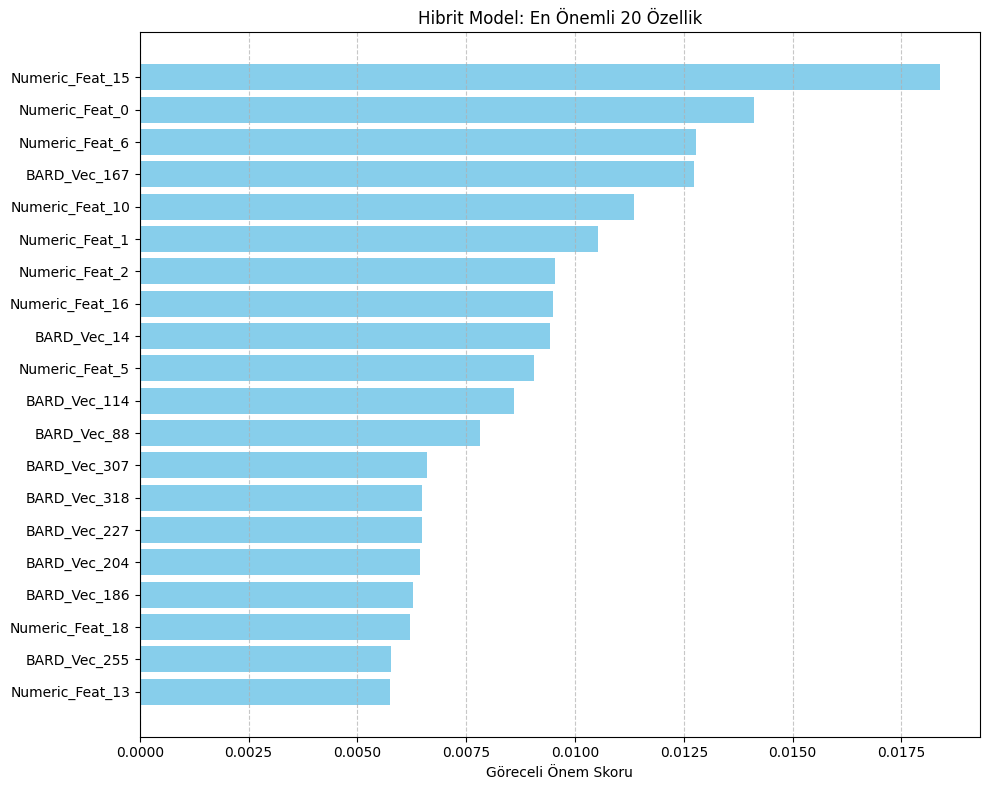

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Özellik isimlerini oluşturma
# İlk 320 tanesi BARDDNA vektörleri, geri kalanı sayısal RF özellikleri
feature_names = [f'BARD_Vec_{i}' for i in range(320)] + [f'Numeric_Feat_{i}' for i in range(X_train_num.shape[1])]

# 2. Modelden önem skorlarını alma
importances = hybrid_rf.feature_importances_
indices = np.argsort(importances)[-20:]  # En önemli 20 özelliği seçiyoruz

# 3. Görselleştirme
plt.figure(figsize=(10, 8))
plt.title("Hibrit Model: En Önemli 20 Özellik")
plt.barh(range(len(indices)), importances[indices], align='center', color='skyblue')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Göreceli Önem Skoru")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [18]:
import joblib
import os

# Klasörün varlığından emin olalım
os.makedirs("../models", exist_ok=True)

# 1. Hibrit Modeli Kaydet
joblib.dump(hybrid_rf, "../models/hybrid_random_forest_v1.pkl")

# 2. Vektör Çıkarıcıyı (Model ve Tokenizer) Kaydetmek Yerine Yolunu Not Ediyoruz
# (Çok büyük oldukları için pkl içine gömmüyoruz, sadece hangi model olduğunu not ediyoruz)
with open("../models/model_info.txt", "w") as f:
    f.write(f"Base Model: {model_ckpt}\n")
    f.write("Input Format: AA_REF AA_ALT GENE_SYMBOL\n")
    f.write(f"Hybrid Feature Count: {X_train_hybrid.shape[1]}")

print("Model ve konfigürasyon başarıyla 'models/' klasörüne kaydedildi!")

Model ve konfigürasyon başarıyla 'models/' klasörüne kaydedildi!
